In [30]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline, XGBMultiOutputPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.7.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,0.318541,0.019632,0.206847,...,0.023251,0.519864,228.689851,6450.512091,11255.133506,1.110311e+09,0.0,1.099041,-45264.048312,-15326.861505
1,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,0.659673,0.269362,0.823100,...,0.881897,0.307468,251.347424,6683.626925,11988.891140,1.032909e+09,0.0,0.463927,-40582.299332,-11855.185093
2,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,0.492968,0.757714,0.625087,...,0.914823,0.078667,184.690777,5766.140732,9659.985315,1.135758e+09,0.0,0.697694,-34042.385712,-48447.698257
3,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,0.185125,0.179946,0.490353,...,0.400283,0.013558,279.158564,7107.472492,12251.510957,1.138632e+09,0.0,0.695005,-48675.889667,5837.705269
4,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,0.692139,0.655440,0.369429,...,0.453588,0.800351,336.834484,7737.210438,12165.795353,1.234887e+09,0.0,0.927158,-50583.469635,6625.620372


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if not(col.startswith("group_"))]
target_cols

['emission_avg_last_five_years',
 'total_emissions',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'num_jobs',
 'earning_per_job']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_nemomod_entc_frac_min_share_production_fp_hydrogen',
 'group_6_nemomod_en',
 'group_7_',
 'group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_9_efficfactor_enfu_industrial_energy_fuel',
 'group_10_scalar_inen_energy_demand',
 'group_11_frac_inen_energy',
 'group_12_frac_ippu_cement_clinker',
 'group_13_ef_ippu_tonne_c',
 'group_14_ef_ippu_tonne_n2o_per_tonne_production',
 'group_15_ef_ippu_tonne_c',
 'group_16_pij_lndu',
 'group_17_frac_lndu_improved_pastures',
 'group_18_lndu_reallocation_factor',
 'group_19_gasrf_lsmm_biogas_anaerobic',
 'group_20_frac_lvst_mm',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm_chickens',
 'group_23_ef_lvst_entferm',
 'group_24_frac_gnrl_eating_red_meat',
 'group_25_frac_ippu_production_with_co2_capture',
 'group_26_scalar_scoe_heat_energy_de

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,9.920000e+02,9.920000e+02,992.000000,9.920000e+02,992.000000,992.000000,992.000000,9.920000e+02
mean,3.248371e+04,5.086004e+05,10254.325628,1.138553e+09,139.813752,0.889860,-39592.533160,2.447592e+04
std,4.940302e+05,4.474598e+06,1421.521382,6.179165e+07,1002.197769,0.225548,8064.785126,1.183487e+06
min,-4.931025e+01,5.397000e+02,589.370368,9.684004e+08,-4.202170,0.260999,-57857.085273,-2.560456e+06
25%,1.348198e+02,5.099397e+03,9359.583337,1.093864e+09,71.395847,0.718062,-44594.502605,-2.286542e+04
50%,1.695130e+02,5.582087e+03,10309.574402,1.140142e+09,84.413017,0.893908,-40050.121047,-5.444068e+03
75%,2.085018e+02,6.132075e+03,11287.253520,1.181488e+09,100.655000,1.071441,-34993.146913,7.432053e+03
max,1.041955e+07,5.210267e+07,12826.445759,1.331854e+09,26099.403287,1.418198,24217.171115,3.704914e+07


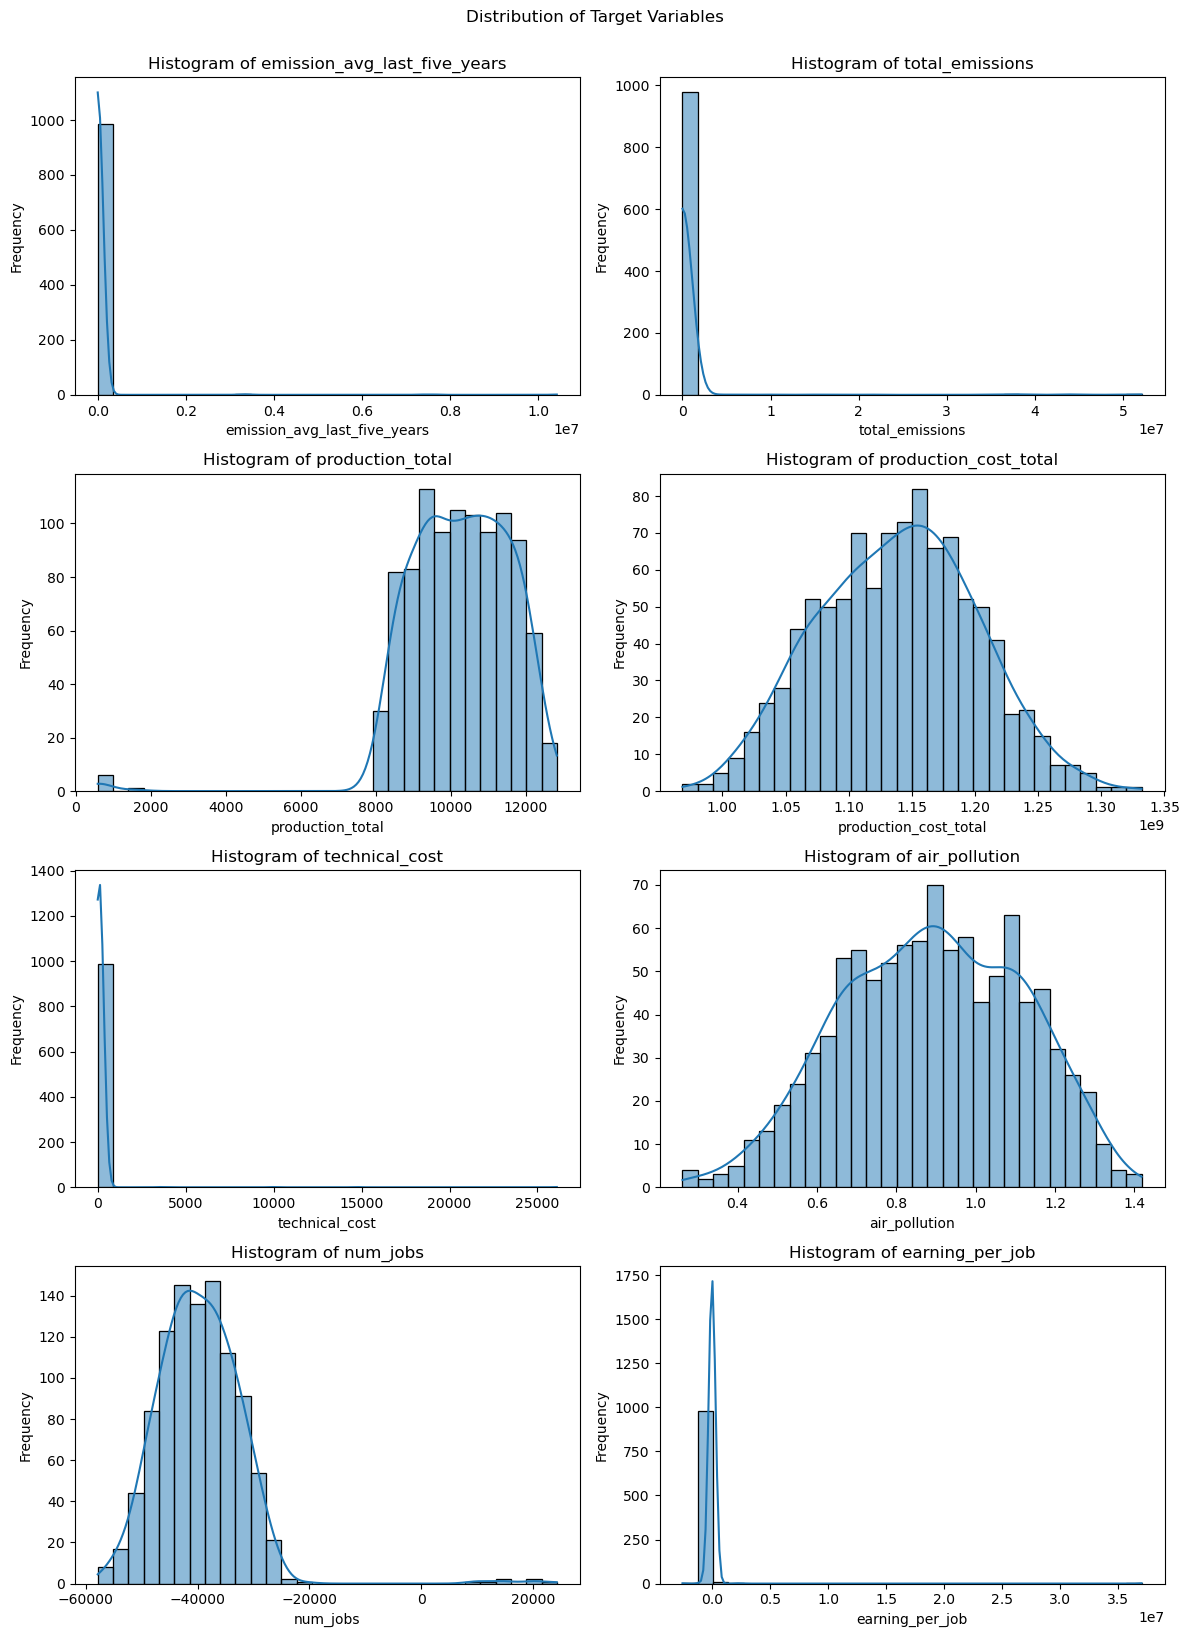

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [11]:
edau.get_target_var_corr(training_df, "total_emissions", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)
	


Correlation with target variable 'total_emissions' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
group_46_exports_enfu_pj_fuel  : 0.8500
group_6_nemomod_en             : 0.1746


Correlation with target variable 'production_cost_total' (threshold: 0.1):
--------------------------------------------------
group_49_scalar_inen_energy_demand_other_product_manufacturing : 0.7413
group_10_scalar_inen_energy_demand : 0.4302
group_48_gdp_mmm_usd           : 0.3574
group_11_frac_inen_energy      : 0.3558


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'air_pollution' (threshold: 0.1):
---------------------------

In [12]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [13]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 1.61, 'total_emissions': 2.12, 'production_total': 0.71, 'production_cost_total': 0.2, 'technical_cost': 1.71, 'num_jobs': 0.71, 'earning_per_job': 7.86}


## Data Cleaning

In [14]:
dcu = DataCleaningUtils()

In [15]:
training_df.shape

(992, 67)

In [16]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [17]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [18]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (992, 67)
Shape after removing outliers: (884, 67)


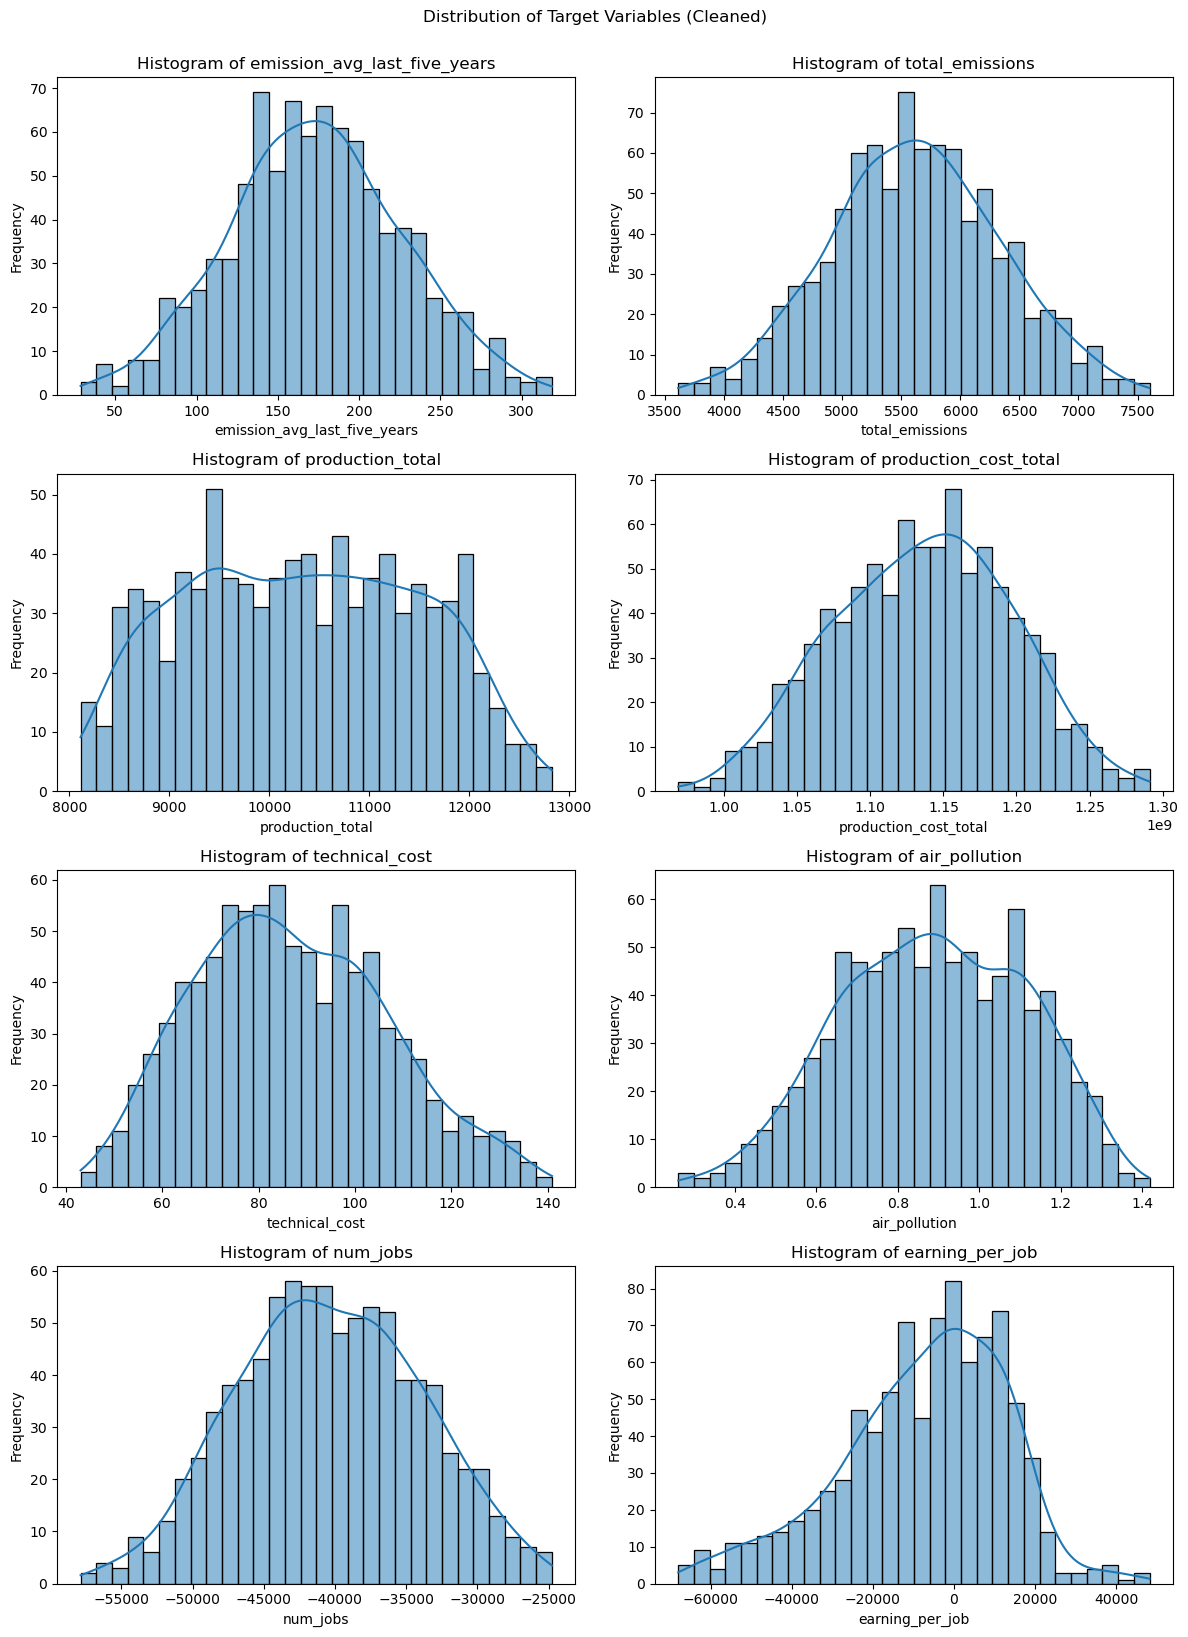

In [19]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [20]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [21]:
edau.get_target_var_corr(training_df, "total_emissions", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)


Correlation with target variable 'total_emissions' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
group_46_exports_enfu_pj_fuel  : 0.8500
group_6_nemomod_en             : 0.1746


Correlation with target variable 'production_cost_total' (threshold: 0.1):
--------------------------------------------------
group_49_scalar_inen_energy_demand_other_product_manufacturing : 0.7413
group_10_scalar_inen_energy_demand : 0.4302
group_48_gdp_mmm_usd           : 0.3574
group_11_frac_inen_energy      : 0.3558


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'air_pollution' (threshold: 0.1):
---------------------------

In [22]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,884.000000,884.000000,884.000000,8.840000e+02,884.000000,884.000000,884.000000,884.000000
mean,173.155938,5620.126325,10320.304035,1.136225e+09,86.845151,0.888883,-40385.485804,-7582.683340
std,53.169828,718.321861,1151.907453,6.014858e+07,19.842028,0.224822,6425.430246,20477.755948
min,28.683706,3612.469170,8113.315973,9.684004e+08,43.090619,0.260999,-57857.085273,-67968.473134
25%,137.291482,5139.555740,9376.002446,1.092555e+09,71.823019,0.719659,-44814.013904,-19875.480316
50%,172.728738,5600.889867,10309.574402,1.138940e+09,85.173717,0.893087,-40499.612155,-4378.642915
75%,208.593691,6106.619219,11257.247351,1.179379e+09,100.794411,1.071441,-35898.920594,7417.830737
max,318.672995,7600.994833,12826.445759,1.291062e+09,140.825705,1.418198,-24774.567319,48157.867524


In [23]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [24]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [ ]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]

In [26]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [27]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training


=== XGB (TEST results) ===
emission_avg_last_five_years   → MAE: 16.3632 | RMSE: 20.8396 | R²: 0.8591 | SMAPE: 10.8%
total_emissions                → MAE: 216.4644 | RMSE: 281.7870 | R²: 0.8602 | SMAPE: 3.9%
production_total               → MAE: 70.2826 | RMSE: 89.3105 | R²: 0.9945 | SMAPE: 0.7%
production_cost_total          → MAE: 11861160.4574 | RMSE: 15180561.4371 | R²: 0.9285 | SMAPE: 1.0%
technical_cost                 → MAE: 3.5631 | RMSE: 4.4345 | R²: 0.9490 | SMAPE: 4.3%
air_pollution                  → MAE: 0.0554 | RMSE: 0.0696 | R²: 0.9087 | SMAPE: 6.9%
num_jobs                       → MAE: 1600.0456 | RMSE: 2090.3566 | R²: 0.9015 | SMAPE: 4.1%
earning_per_job                → MAE: 7997.0058 | RMSE: 11013.6148 | R²: 0.6658 | SMAPE: 77.6%

=== Cross-Validation (TEST only) ===
emission_avg_last_five_years   → MAE: 16.8789 ± 0.8504 | RMSE: 21.4542 ± 1.0346 | R²: 0.8314 ± 0.0182
total_emissions                → MAE: 228.0556 ± 11.1701 | RMSE: 284.9877 ± 15.5731 | R²: 0.8357 ± 

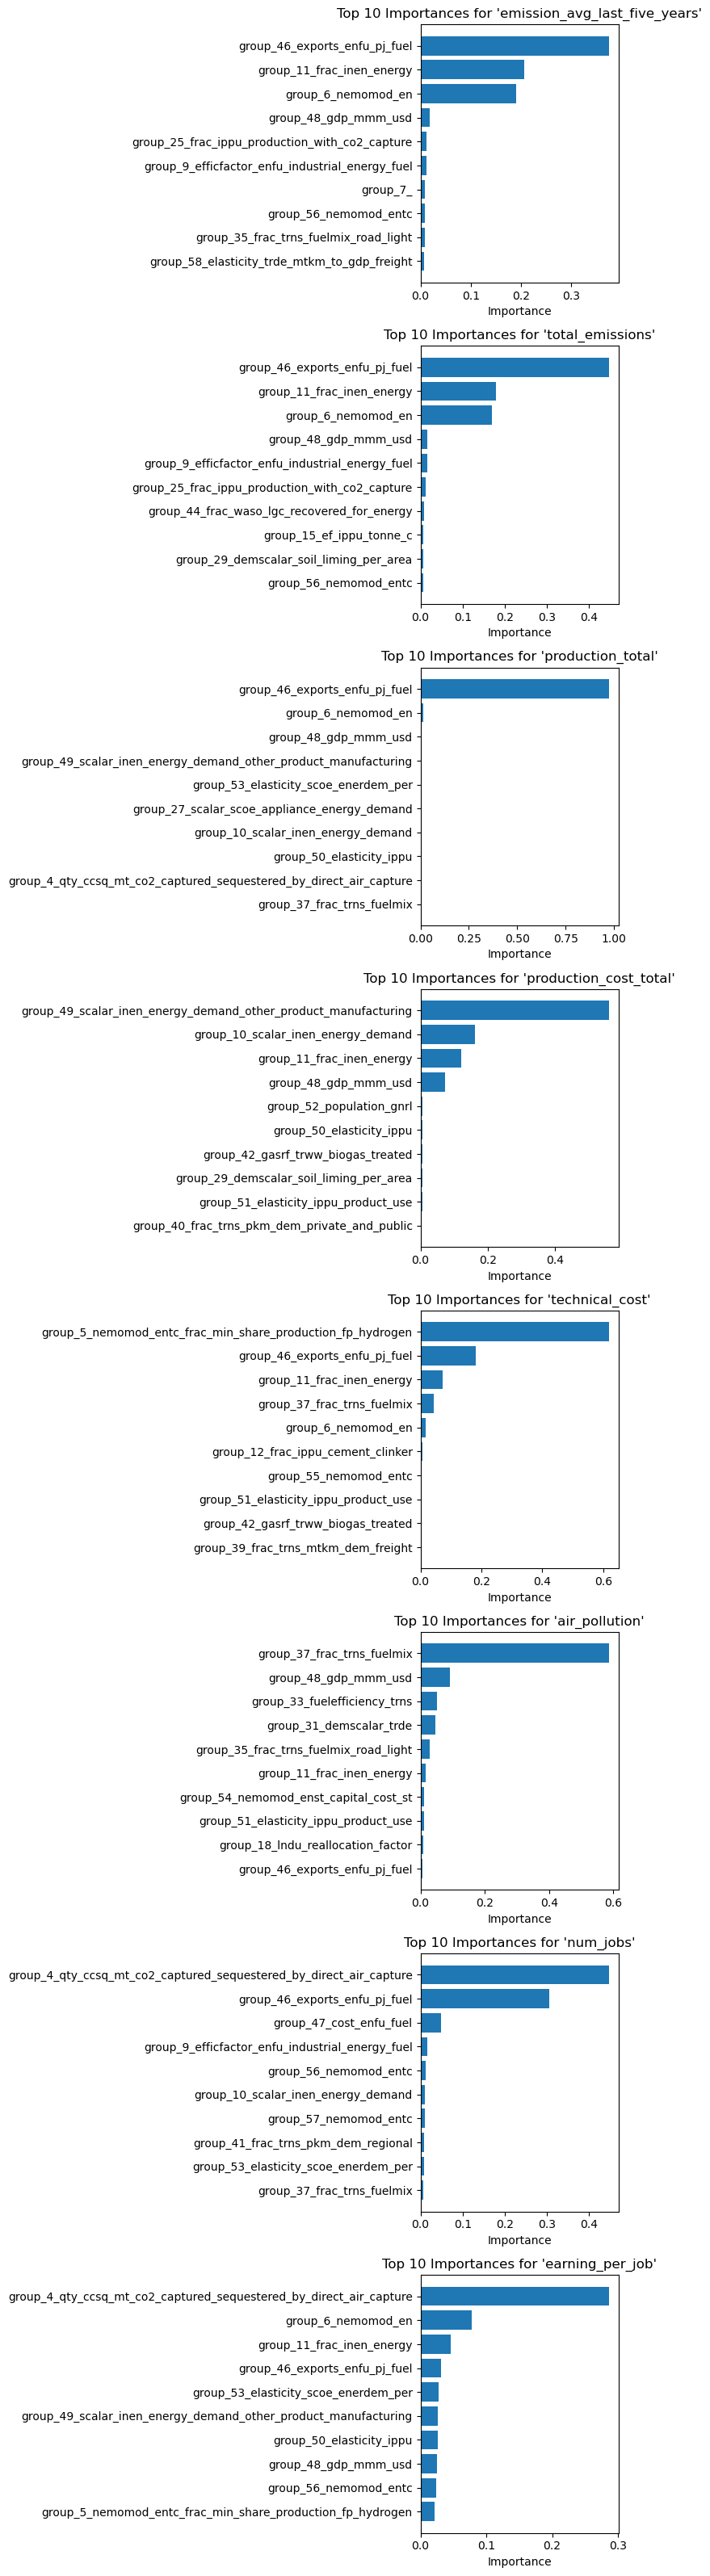

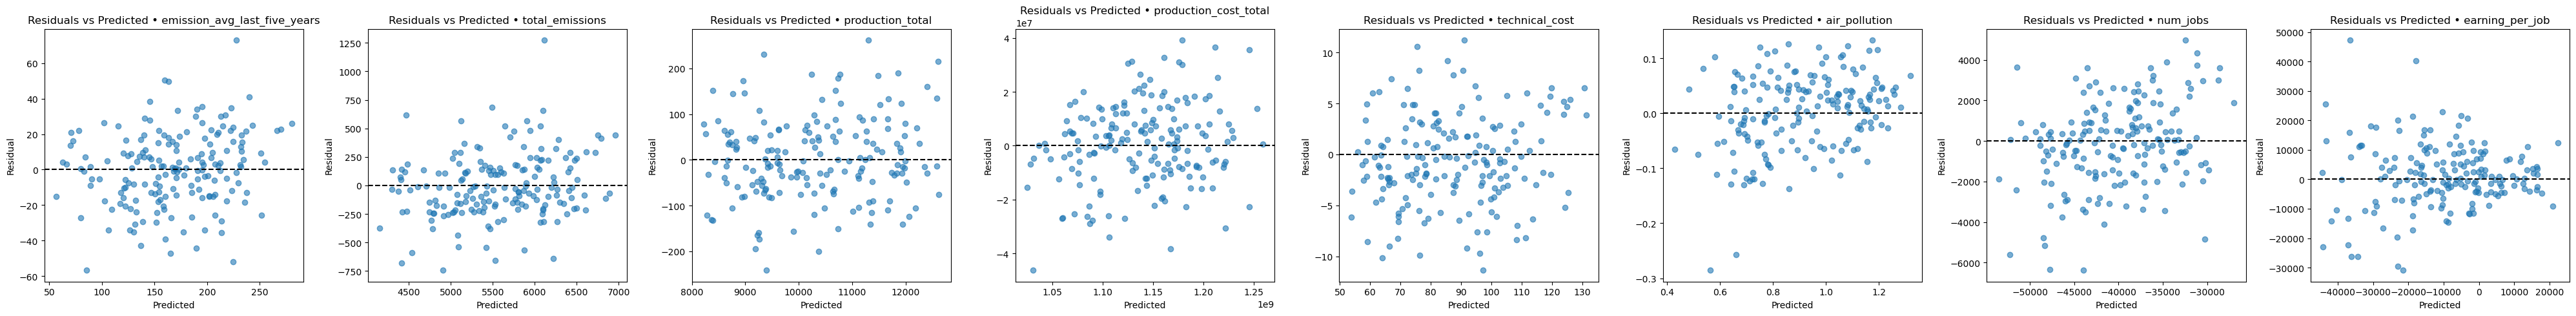

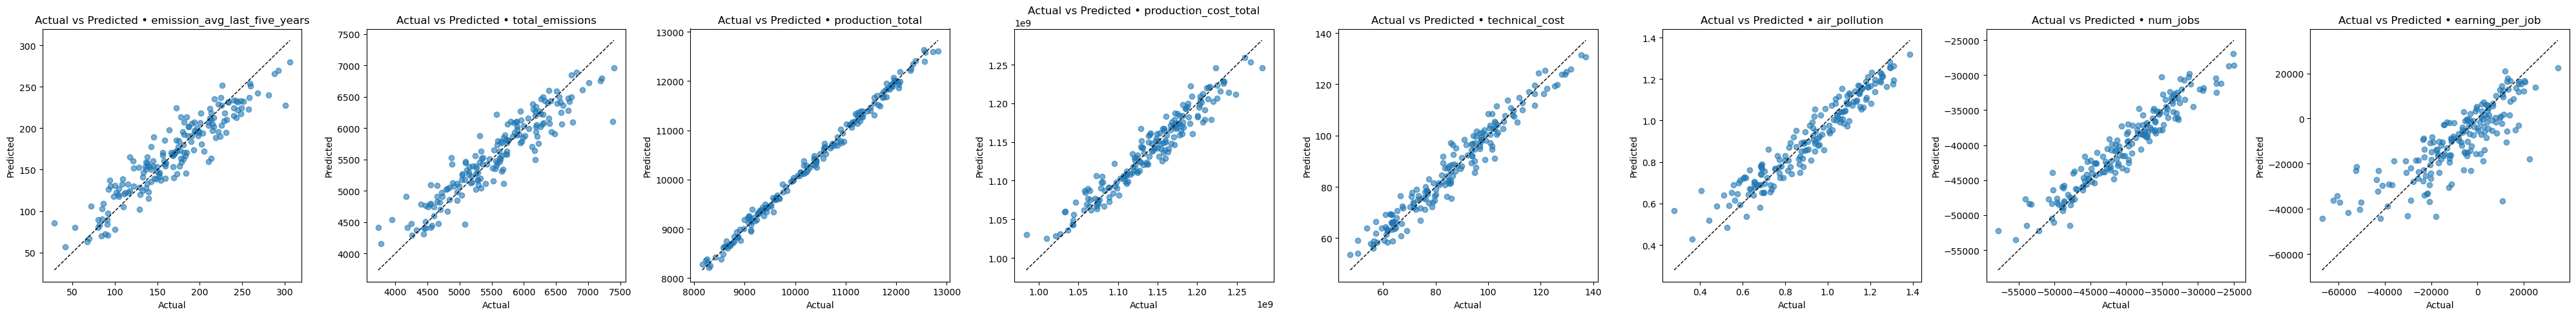

In [31]:
mulp = XGBMultiOutputPipeline(df=training_df_cleaned, targets=target_cols)
mulp.run(tune=False, log_transform=False, plot_figures=True)


=== XGB ===
emission_avg_last_five_years  
  Train → MAE: 0.0042, RMSE: 0.0058, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 16.3632, RMSE: 20.8396, R²: 0.8591, SMAPE: 10.8%
total_emissions               
  Train → MAE: 0.0498, RMSE: 0.0710, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 216.4644, RMSE: 281.7870, R²: 0.8602, SMAPE: 3.9%
production_total              
  Train → MAE: 0.0371, RMSE: 0.0515, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 70.2826, RMSE: 89.3105, R²: 0.9945, SMAPE: 0.7%
production_cost_total         
  Train → MAE: 7010.5517, RMSE: 9745.8176, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 11861160.4574, RMSE: 15180561.4371, R²: 0.9285, SMAPE: 1.0%
technical_cost                
  Train → MAE: 0.0013, RMSE: 0.0017, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 3.5631, RMSE: 4.4345, R²: 0.9490, SMAPE: 4.3%
air_pollution                 
  Train → MAE: 0.0004, RMSE: 0.0005, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 0.0554, RMSE: 0.0696, R²: 0.9087, SMAPE: 6.9%
num_jobs                      
  Train →

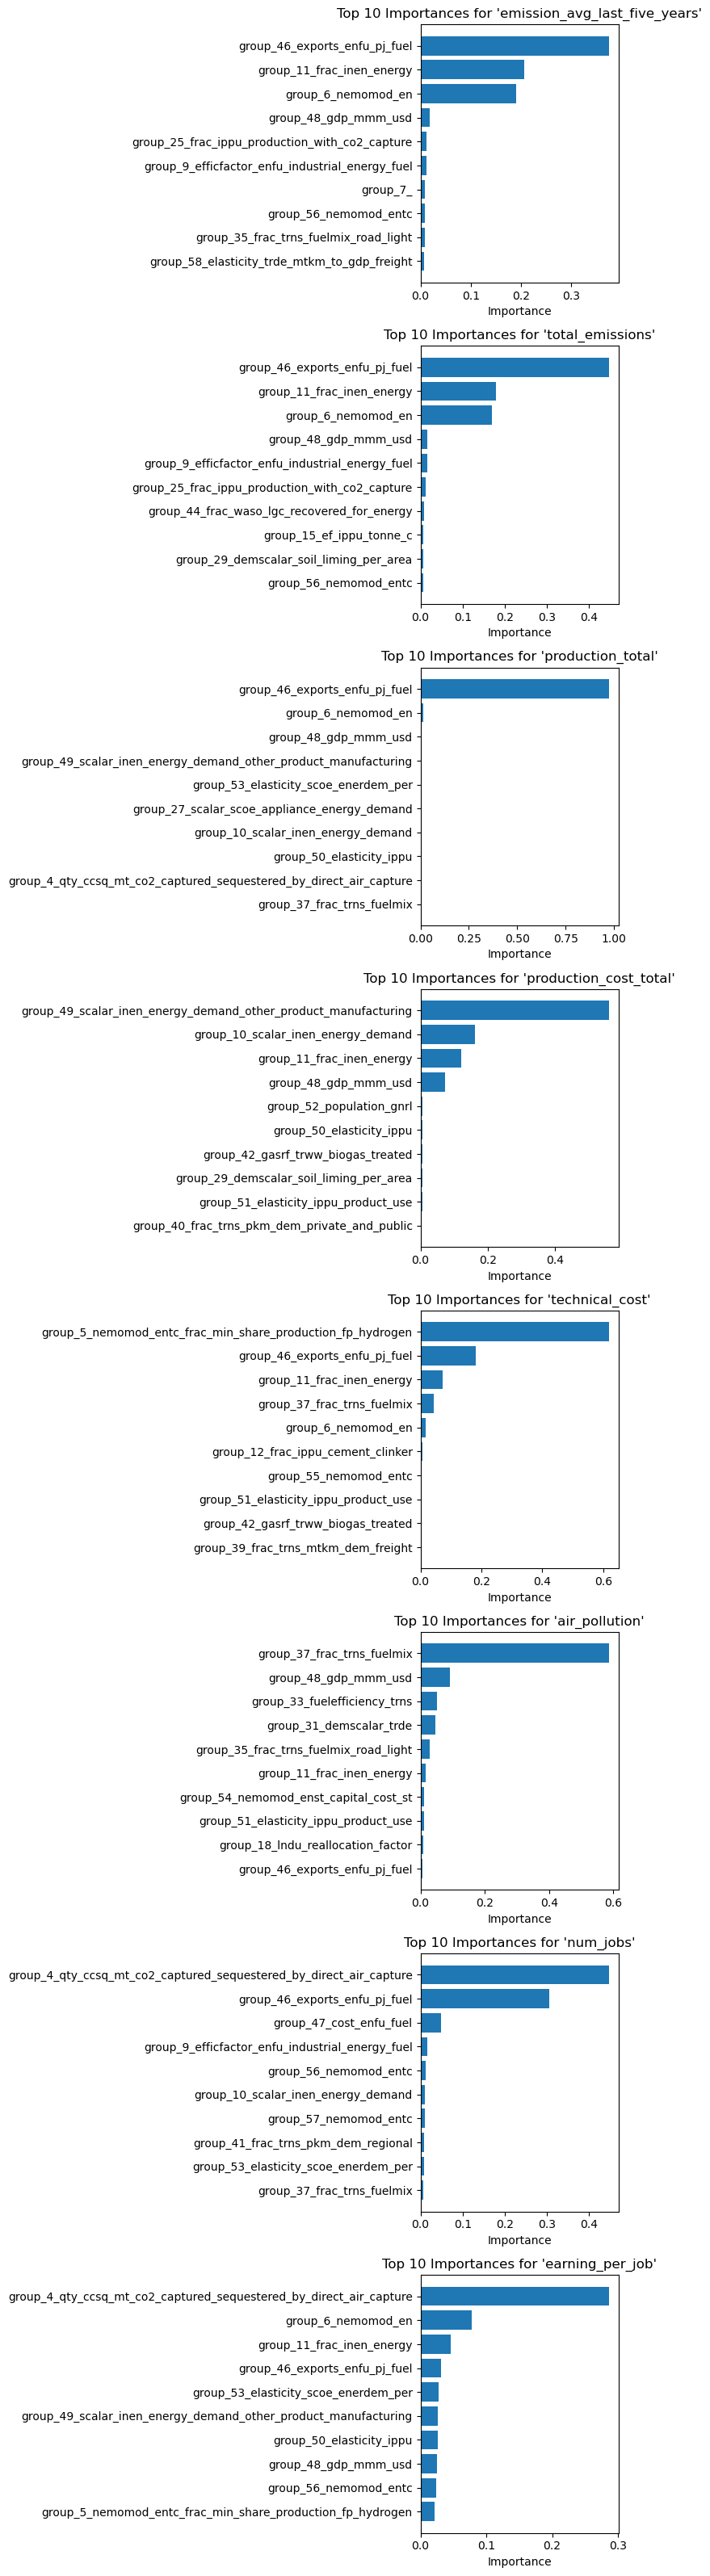

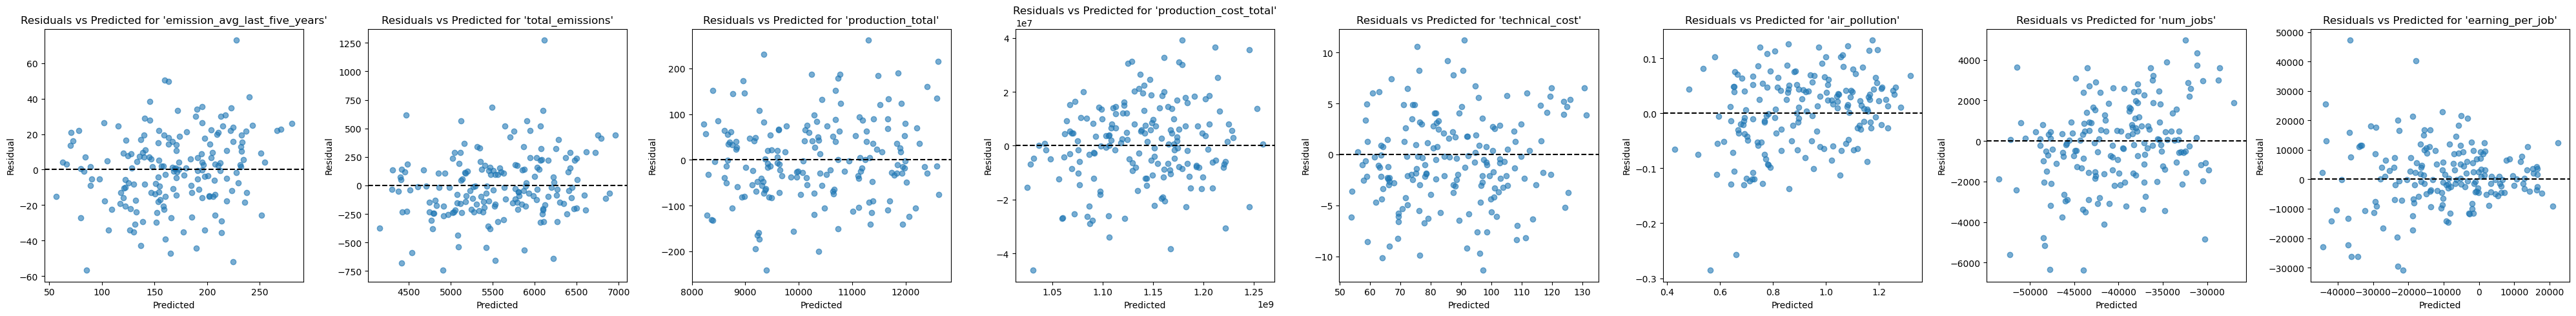

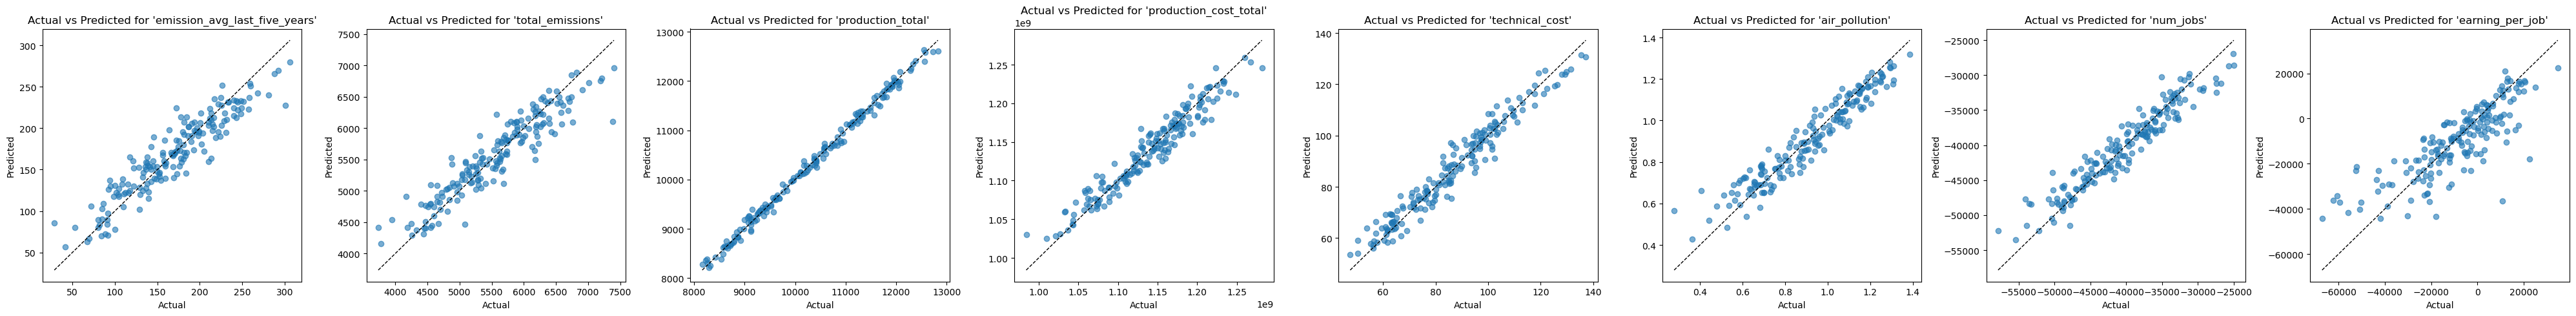

In [ ]:
# mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=target_cols)
# mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [20]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.792661,0.700647,134.250713,4713.726381,279.612528,4.567414e+08,-2.275659,1.033437,7184.221916,69844.538790
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,276.395578,4.708078e+08,-7.468213,0.753391,10553.138793,114591.865227
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,264.412432,4.615890e+08,-3.833560,1.181780,10329.819880,61421.909034
4,0.057338,0.477879,0.866591,0.161689,0.282495,0.282664,0.310182,0.991945,0.953932,0.864061,...,0.048358,0.042901,187.314145,5488.927406,243.699542,4.032488e+08,-6.069652,0.963409,8311.856268,132260.785244
5,0.511133,0.698963,0.711505,0.683995,0.437127,0.227332,0.355119,0.640986,0.844816,0.833615,...,0.256756,0.677597,154.259184,5011.043324,250.400601,4.181826e+08,-4.700765,0.677055,11844.335272,88061.428521


In [21]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(target_cols)
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.653223,0.662849,0.115262,0.601828,0.954157,0.508737,0.781123,0.313322,0.792661,0.700647


In [22]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    132.947678     4727.477539        279.481415   

   production_cost_total  technical_cost  air_pollution     num_jobs  \
0            456510592.0       -2.149045       0.907394  7174.820312   

   earning_per_job  
0     64290.136719  
Original values:
emission_avg_last_five_years    1.342507e+02
emission_total                  4.713726e+03
production_total                2.796125e+02
production_cost_total           4.567414e+08
technical_cost                 -2.275659e+00
air_pollution                   1.033437e+00
num_jobs                        7.184222e+03
earning_per_job                 6.984454e+04
Name: 0, dtype: float64


In [23]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.5.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.5.pkl to e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\trained_models\xgb_pipeline_5.5.pkl.


In [24]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [25]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    132.947678     4727.477539        279.481415   

   production_cost_total  technical_cost  air_pollution     num_jobs  \
0            456510592.0       -2.149045       0.907394  7174.820312   

   earning_per_job  
0     64290.136719  


In [26]:
from pathlib import Path
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)
mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.5_x_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.5_y_test.parquet")


In [27]:
training_df_cleaned.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.5_training_df.parquet")

In [28]:
training_df_cleaned

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.792661,0.700647,134.250713,4713.726381,279.612528,4.567414e+08,-2.275659,1.033437,7184.221916,69844.538790
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,276.395578,4.708078e+08,-7.468213,0.753391,10553.138793,114591.865227
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,264.412432,4.615890e+08,-3.833560,1.181780,10329.819880,61421.909034
4,0.057338,0.477879,0.866591,0.161689,0.282495,0.282664,0.310182,0.991945,0.953932,0.864061,...,0.048358,0.042901,187.314145,5488.927406,243.699542,4.032488e+08,-6.069652,0.963409,8311.856268,132260.785244
5,0.511133,0.698963,0.711505,0.683995,0.437127,0.227332,0.355119,0.640986,0.844816,0.833615,...,0.256756,0.677597,154.259184,5011.043324,250.400601,4.181826e+08,-4.700765,0.677055,11844.335272,88061.428521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,0.635142,0.603678,0.650826,0.938293,0.532791,0.458046,0.964056,0.549375,0.406465,0.937233,...,0.815408,0.150082,121.594420,4691.472707,248.818823,4.102299e+08,-4.849271,0.827842,20074.832845,91639.779457
959,0.523444,0.024740,0.631766,0.447112,0.909923,0.343413,0.604907,0.239868,0.477267,0.551167,...,0.710320,0.501973,162.146717,5202.036088,269.682673,4.655390e+08,-8.026771,0.250140,13488.129216,116293.548455
960,0.480615,0.560271,0.266827,0.643640,0.040585,0.020424,0.617931,0.743517,0.274302,0.251297,...,0.957187,0.471602,194.313061,5592.469537,292.994094,5.283043e+08,-5.954081,0.030116,16191.791192,78560.507381
961,0.083011,0.230503,0.294934,0.197481,0.891935,0.140418,0.135728,0.777188,0.748830,0.282061,...,0.979377,0.900547,200.981586,5717.910263,282.274217,4.902101e+08,-7.731554,0.563744,6795.072635,73039.006672
